# Lecture 20: AI-assisted code writing (aka "Vibe-coding")
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PIMILab/ENGR1050/blob/main/notebooks/lec20.ipynb)


In [2]:
# Run this cell to set up the notebook environment

import os
import urllib.request

# Create Data directory if it doesn't exist
if not os.path.exists('Data'):
    os.makedirs('Data')

# Download the CSV file from GitHub if it doesn't exist locally
csv_file_path = 'Data/Exam_Grades_Anonymized.csv'
if not os.path.exists(csv_file_path):
    github_url = 'https://raw.githubusercontent.com/PIMILab/ENGR1050/main/notebooks/Data/Exam_Grades_Anonymized.csv'
    urllib.request.urlretrieve(github_url, csv_file_path)
    print(f"Downloaded {csv_file_path}")
else:
    print(f"{csv_file_path} already exists")

Downloaded Data/Exam_Grades_Anonymized.csv


## Overview

For today's lecture, you will be learning to use Gemini, Google's large language model (LLM) AI that is built into Google colab. This is an incredibly tricky topic fraught with both ethical and strategic concerns for how best to prepare you for your own career. There are two realities:

1. If you become too dependent on AI, you will not have any core programming skills and will not be able to adapt to new technologies or the very real possibility that large language models may not be available in the current incarnation forever.
2. Your professional competition will be using AI to get a very non-trivial multiplier on their productivity. If you ignore it, you will be at a very real professional disadvantage.

As engineers, AI gives us a very cool opportunity to be able to rapidly work with libraries that traditionally have taken a long time to learn - this is a **golden age for hacking together prototypes**. If there is a new component to e.g. a Pico that you want to learn to use, you can easily get instructions and basic code to quickly put together a prototype. I have two objectives for the next unit of the course:

1. You get confident using a LLM like Gemini to quickly get productive working with a new library.
2. You understand the realities of what machine learning is doing - it is not sentient, and has fundamental limitations. If you are literate in the basics of how it works, you can better understand when it is safe to use it.

# Getting your Google colab set up to use Gemini

In the slides from today, I explained how to turn on the code auto-complete and the generative AI capabilities in Google Colab

- Make a new jupyter notebook
- Click the Settings Icon
- Under `AI Assistance`
    - Check `Show AI-powered inline completions`
    - Check Consented to use generative AI features

This can be very annoying if you don't want AI constantly popping up and telling you what to do - you can always go back into Settings and turn this off.

# Dialing in reasonable responses

We will step through two questions to give you a sense of the quality of responses that the LLM can generate. At the core, this is something similar to a glorified search engine (we'll learn more details in the next few weeks). This means that tasks that have been done many times before will be executed well. Large, open-ended tasks or original tasks requiring creative solutions will fail (although sometimes you can get surprisingly good results).

**TODO:** Give Gemini the following prompt, asking it to solve the Question 4 from Exam 2.
```
Write a for loop that implements the explicit Euler method to solve the following ODE: ̇y = −3y Use the initial condition y(0) = 5, a time step size of h = 0.1, and compute the solution from t = 0 to t = 2. You can store the solution in either a list or a Numpy array.
```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the ODE
def dydt(y):
    return -3 * y

# Initial condition
y0 = 5

# Time step size
h = 0.1

# Time span
t_start = 0
t_end = 2

# Number of steps
n_steps = int((t_end - t_start) / h)

# Initialize lists to store results
t_values = [t_start]
y_values = [y0]

# Explicit Euler method
y = y0
for i in range(n_steps):
    t = t_values[-1]
    dy = dydt(y)
    y = y + dy * h
    t = t + h
    t_values.append(t)
    y_values.append(y)

# Display the results (optional)
# print("Time values:", t_values)
# print("Y values:", y_values)

# You can also plot the results
# plt.plot(t_values, y_values)
# plt.xlabel("Time")
# plt.ylabel("y")
# plt.title("Solution of dy/dt = -3y using Explicit Euler")
# plt.grid(True)
# plt.show()

**TODO:** Give Gemini the following prompt, asking it to generate code to replicate the helicopter project.
```
Generate pico code to make a 1d helicopter attached to a pendulum levitate at a desired angle and buttons that make it go up and down
```

# LLMs are good at standard tasks that many people have done before, like plotting

**Exercise:** I've anonymized the scores from Exam 2 and put them in a CSV file in `notebooks/Data/Exam_Grades_Anonymized.csv`. Run the following prompts to load the CSV file and generate a plot to help compare exam grades.

1. ```write code to load in the Data\exam_grades_anonymized.csv file and save as a list```
2. ```generate a histogram of the grades along with the median and +/- 1stdev as vertical bar and shaded vertical regions. both plots should have the same x axis, and the same y axis scale and tick marks```

In [7]:
import csv

exam1_grades = []
exam2_grades = []
csv_file_path = 'Data/Exam_Grades_Anonymized.csv'

with open(csv_file_path, mode='r') as file:
    csv_reader = csv.reader(file)
    # Assuming the first row is a header, skip it
    header = next(csv_reader)

    all_grades = []
    # Read all grades from the first column into a single list
    for row in csv_reader:
         try:
            grade = float(row[0]) # Assuming grade is in the first column
            all_grades.append(grade)
         except (ValueError, IndexError) as e:
            print(f"Skipping row due to error: {row} - {e}")

    # Assuming the first half are Exam 1 and the second half are Exam 2
    mid_point = len(all_grades) // 2
    exam1_grades = all_grades[:mid_point]
    exam2_grades = all_grades[mid_point:]


print(f"Loaded {len(exam1_grades)} grades for Exam 1.")
print(f"Loaded {len(exam2_grades)} grades for Exam 2.")
# Display the first few grades to verify
print("Exam 1 grades (first 10):", exam1_grades[:10])
print("Exam 2 grades (first 10):", exam2_grades[:10])

Loaded 35 grades for Exam 1.
Loaded 35 grades for Exam 2.
Exam 1 grades (first 10): [95.0, 94.0, 97.0, 97.0, 89.0, 98.0, 99.0, 93.0, 62.0, 97.0]
Exam 2 grades (first 10): [96.0, 85.0, 95.0, 97.0, 90.0, 96.0, 83.0, 100.0, 64.0, 97.0]


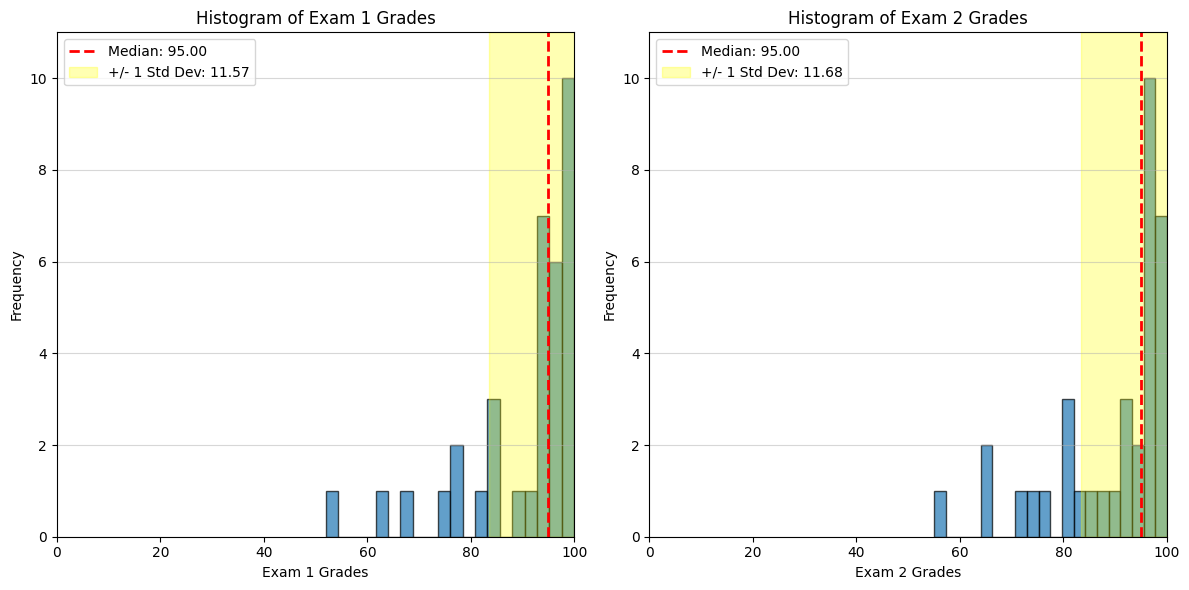

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate median and standard deviation for Exam 1
median_grade_exam1 = np.median(exam1_grades)
std_dev_exam1 = np.std(exam1_grades)

# Calculate median and standard deviation for Exam 2
median_grade_exam2 = np.median(exam2_grades)
std_dev_exam2 = np.std(exam2_grades)

# Create the histogram for Exam 1
plt.figure(figsize=(12, 6)) # Adjust figure size as needed

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.hist(exam1_grades, bins=20, edgecolor='black', alpha=0.7) # Adjust number of bins as needed
plt.axvline(median_grade_exam1, color='red', linestyle='dashed', linewidth=2, label=f'Median: {median_grade_exam1:.2f}')
plt.axvspan(median_grade_exam1 - std_dev_exam1, median_grade_exam1 + std_dev_exam1, color='yellow', alpha=0.3, label=f'+/- 1 Std Dev: {std_dev_exam1:.2f}')
plt.xlabel("Exam 1 Grades")
plt.ylabel("Frequency")
plt.title("Histogram of Exam 1 Grades")
plt.legend()
plt.grid(True, axis='y', alpha=0.5)
plt.xlim(0, 100) # Example limits assuming grades are between 0 and 100


# Create the histogram for Exam 2
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.hist(exam2_grades, bins=20, edgecolor='black', alpha=0.7) # Adjust number of bins as needed
plt.axvline(median_grade_exam2, color='red', linestyle='dashed', linewidth=2, label=f'Median: {median_grade_exam2:.2f}')
plt.axvspan(median_grade_exam2 - std_dev_exam2, median_grade_exam2 + std_dev_exam2, color='yellow', alpha=0.3, label=f'+/- 1 Std Dev: {std_dev_exam2:.2f}')
plt.xlabel("Exam 2 Grades")
plt.ylabel("Frequency")
plt.title("Histogram of Exam 2 Grades")
plt.legend()
plt.grid(True, axis='y', alpha=0.5)
plt.xlim(0, 100) # Example limits assuming grades are between 0 and 100

# Ensure both plots have the same y-axis limits for comparison
max_freq_exam1 = np.max(np.histogram(exam1_grades, bins=20)[0])
max_freq_exam2 = np.max(np.histogram(exam2_grades, bins=20)[0])
max_freq = max(max_freq_exam1, max_freq_exam2)

plt.subplot(1, 2, 1).set_ylim(0, max_freq * 1.1) # Add a little padding
plt.subplot(1, 2, 2).set_ylim(0, max_freq * 1.1) # Add a little padding


plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

### LLMs are good at explaining complicated code

**Exercise:** Below is the code from the `ButtonClass` in Lab 3 and Exam 2. Ask Gemini to explain this code. You can do this a few ways.
1. Give a prompt `"explain the following code: "` and then copy and paste the code
2. Paste it into a code block, and click on the code block, and then prompt `explain ButtonClass in the highlighted block`

The response you get is a **dialog**. You can continue to ask questions. Keep asking questions about the code and use the responses to complete the `TODO` below.

**TODO:** In your Jupyter notebook, add a markdown box explaining what `newbuttonstate` and `oldbuttonstate` are doing, and why we need to add the `debouncing` line. Use quotes to distinguish your thoughts from Gemini's "thoughts", e.g.
<center>

*Gemini says "XYZ". I think this is true because XYZ*

</center>

In [ ]:
from machine import Pin
import time

# A class to catch when buttons are pressed
class ButtonClass:
    """
    A class to detect button press events on a Raspberry Pi Pico.

    This class handles button debouncing and edge detection, returning True
    only when a button press event occurs (transition from not pressed to pressed).
    """

    def __init__(self, pin_number):
        """
        Initialize the button class.

        Args:
            pin_number (int): GPIO pin number where the button is connected

        Note:
            Button should be wired with one side to the specified pin and
            the other side to 3.3V. The internal pull-down resistor is enabled.
        """
        self.button = Pin(pin_number, Pin.IN, Pin.PULL_DOWN)

        # Store the button value at start to detect state changes
        self.oldbuttonstate = self.button.value()

    def catchPress(self):
        """
        Check if a button press event has occurred.

        This method detects the rising edge of a button press (transition from
        low to high) and returns True only once per press event.

        Returns:
            bool: True if a button press was detected, False otherwise

        Note:
            This method includes a small delay (0.01s) for basic debouncing.
            It should be called repeatedly in a loop to monitor button state.
        """
        # Check if any of the buttons have flipped their state
        newbuttonstate = self.button.value()

        if self.oldbuttonstate == 0 and newbuttonstate == 1:
            # A button press was detected (rising edge)
            self.oldbuttonstate = newbuttonstate
            return True

        # Update the old state for next iteration
        self.oldbuttonstate = newbuttonstate

        # Small delay for debouncing
        time.sleep(0.01)
        return False

Gemini says "oldbuttonstate and newbuttonstate are used to track the button's change in state to identify a press, and the debouncing delay prevents the code from reacting to the noisy signals caused by button bounce."

I think this is true because Oldbuttonstate just looks at the value of the button currently and newbuttonstate looks for changes in the value of the button and if it does change it updates the button state. The debouncing part gets rid of accidental changes by making a small delay.



# Today's exercise: Use Gemini to learn how to use an API

An Application Programming Interface, or API, is a set of functions that allow you to write programs that integrate with complicated systems. For example:
- Weather APIs let you write a program that query the current weather at a given latitude and longitude
- Social media APIs let you automatically write posts to Twitter or Facebook
- Payment APIs let you use PayPal or Stripe to process financial transactions
- Map APIs like Google Maps lets you coordinate latitude and longitude

In the old days (two years ago) software engineers would spend months learning the ins and outs of a given API. To design an app, you might get people together who know the Payment API and another who knows a Database API and together they would team up to design an App that could e.g. be used to run a fundraising campaign based on information gathered about client lists (my wife works in non-profit fundraising).

For better or for worse, you can use LLMs to quickly throw together the basics of an API. It is **dangerous** - you are using a code generated without a human in the loop to potential process sensitive information, the code may be incorrect, or even worse, intentionally expose a vulerability that can be exploited by malicious actors. In the engineering world, things are both lower and higher stakes. Most people aren't interested in intercepting our potentiometer readings and figuring out what angle our helicopter is hovering at. But peoples lives do depend on whether we design a bridge that collapses or an airbag that doesn't activate because we used sloppy AI-designed code.

# This weeks assignment: Vibe code a data collection tool

We will use a LLM to help us learn how to use the Google suite's API to collect data from a Google form and into python lists. We will use this code for the next few weeks to collect data from surveys that we can use to do some machine learning.

In a group of 2-4, you should:
- Generate a google form that asks whether students are Freshman/Sophomore/Junior/Senior.
- Fill in a few sample responses.
- Use the google API to extract the responses as a list.
- Make a histogram of the results.

**Note.** This exercise is meant to give you the full experience of using AI to write code. It is frustrating and doesn't always work, but with persistence you can build something that would be much more sophisticated than any beginner coder would be able to attempt (this is a good and a bad thing).

Start by feeding Gemini the following prompt, and then **independently** iterate from there, asking Gemini for help.

**Prompt:** ```i am generating a google form and would like to develop an interface to pull the results of the form into this notebook to process as python lists. give instructions for how to do this```

# Submit today's work #
Today's assignment will be submitted by groups of 2-4. Submit a screenshot of your google form along with a screenshot of a histogram showing that you successfully extracted the output of the form.

Submit to Canvas using the following [link](https://canvas.upenn.edu/courses/1881448/assignments/14080981).